### Load the required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('50_Startups.csv')

In [3]:
df.head(10)

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [4]:
df.shape # to get the shape of the dataset

(50, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


### Exploratory data analysis

In [7]:
# 1. to check null values are there or not
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [8]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


### analyzing vategorical variable

In [9]:
df.describe(include = ['object'])

,State
count,50
unique,3
top,New York
freq,17


In [10]:
df['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

In [11]:
df_state = pd.get_dummies(df["State"], prefix = "State", dtype= int)

In [12]:
df_state

,State_California,State_Florida,State_New York
0,0,0,1
1,1,0,0
2,0,1,0
3,0,0,1
4,0,1,0
5,0,0,1
6,1,0,0
7,0,1,0
8,0,0,1
9,1,0,0


In [13]:
dfDummmies = pd.get_dummies(df["State"], prefix = "State", dtype= int)
dfDummmies

,State_California,State_Florida,State_New York
0,0,0,1
1,1,0,0
2,0,1,0
3,0,0,1
4,0,1,0
5,0,0,1
6,1,0,0
7,0,1,0
8,0,0,1
9,1,0,0


In [15]:
df = pd.concat([df, dfDummmies], axis = 1)

In [16]:
df

,R&D Spend,Administration,Marketing Spend,State,Profit,State_California,State_Florida,State_New York
0,165349.20,136897.80,471784.10,New York,192261.83,0,0,1
1,162597.70,151377.59,443898.53,California,191792.06,1,0,0
2,153441.51,101145.55,407934.54,Florida,191050.39,0,1,0
3,144372.41,118671.85,383199.62,New York,182901.99,0,0,1
4,142107.34,91391.77,366168.42,Florida,166187.94,0,1,0
5,131876.90,99814.71,362861.36,New York,156991.12,0,0,1
6,134615.46,147198.87,127716.82,California,156122.51,1,0,0
7,130298.13,145530.06,323876.68,Florida,155752.60,0,1,0
8,120542.52,148718.95,311613.29,New York,152211.77,0,0,1
9,123334.88,108679.17,304981.62,California,149759.96,1,0,0


In [17]:
df = df.drop(['State', 'State_Florida'], axis =1)

In [18]:
df

,R&D Spend,Administration,Marketing Spend,Profit,State_California,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,1,0
2,153441.51,101145.55,407934.54,191050.39,0,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,0,0
5,131876.90,99814.71,362861.36,156991.12,0,1
6,134615.46,147198.87,127716.82,156122.51,1,0
7,130298.13,145530.06,323876.68,155752.60,0,0
8,120542.52,148718.95,311613.29,152211.77,0,1
9,123334.88,108679.17,304981.62,149759.96,1,0


In [21]:
x=  df.drop(['Profit'], axis = 1)   # input featurees
y=  df['Profit']   # output variable

In [22]:
x

,R&D Spend,Administration,Marketing Spend,State_California,State_New York
0,165349.20,136897.80,471784.10,0,1
1,162597.70,151377.59,443898.53,1,0
2,153441.51,101145.55,407934.54,0,0
3,144372.41,118671.85,383199.62,0,1
4,142107.34,91391.77,366168.42,0,0
5,131876.90,99814.71,362861.36,0,1
6,134615.46,147198.87,127716.82,1,0
7,130298.13,145530.06,323876.68,0,0
8,120542.52,148718.95,311613.29,0,1
9,123334.88,108679.17,304981.62,1,0


In [23]:
y

0     192261.83
1     191792.06
2     191050.39
3     182901.99
4     166187.94
5     156991.12
6     156122.51
7     155752.60
8     152211.77
9     149759.96
10    146121.95
11    144259.40
12    141585.52
13    134307.35
14    132602.65
15    129917.04
16    126992.93
17    125370.37
18    124266.90
19    122776.86
20    118474.03
21    111313.02
22    110352.25
23    108733.99
24    108552.04
25    107404.34
26    105733.54
27    105008.31
28    103282.38
29    101004.64
30     99937.59
31     97483.56
32     97427.84
33     96778.92
34     96712.80
35     96479.51
36     90708.19
37     89949.14
38     81229.06
39     81005.76
40     78239.91
41     77798.83
42     71498.49
43     69758.98
44     65200.33
45     64926.08
46     49490.75
47     42559.73
48     35673.41
49     14681.40
Name: Profit, dtype: float64

### train the model

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = .3, random_state = 0) 

In [33]:
from sklearn.linear_model import LinearRegression
ls= LinearRegression()

In [34]:
model = ls.fit(X_train, y_train)

In [35]:
y_pred = model.predict(X_test)

In [36]:
y_pred

array([104282.76472165, 132536.88499217, 133910.8500777 ,  72584.7748942 ,
       179920.92761895, 114549.31079231,  66444.43261351,  98404.9684012 ,
       114499.828086  , 169367.50639901,  96522.62539982,  88040.67182874,
       110949.99405524,  90419.18978504, 128020.46250065])

In [37]:
df = pd.DataFrame({"y_test" : y_test, "y_pred": y_pred," diff between y_pred and y_test": abs(y_pred - y_test) })

In [38]:
df

,y_test,y_pred,diff between y_pred and y_test
28,103282.38,104282.764722,1000.384722
11,144259.40,132536.884992,11722.515008
10,146121.95,133910.850078,12211.099922
41,77798.83,72584.774894,5214.055106
2,191050.39,179920.927619,11129.462381
27,105008.31,114549.310792,9541.000792
38,81229.06,66444.432614,14784.627386
31,97483.56,98404.968401,921.408401
22,110352.25,114499.828086,4147.578086
4,166187.94,169367.506399,3179.566399


### evaluate the model

In [39]:
from sklearn.metrics import mean_squared_error, r2_score

In [40]:
print("Mean squared error: ", mean_squared_error(y_test, y_pred))
print("r2 score: ", r2_score(y_test, y_pred))

Mean squared error:  61903144.40205623
r2 score:  0.9358680970049738


### plot Actual vs predicted

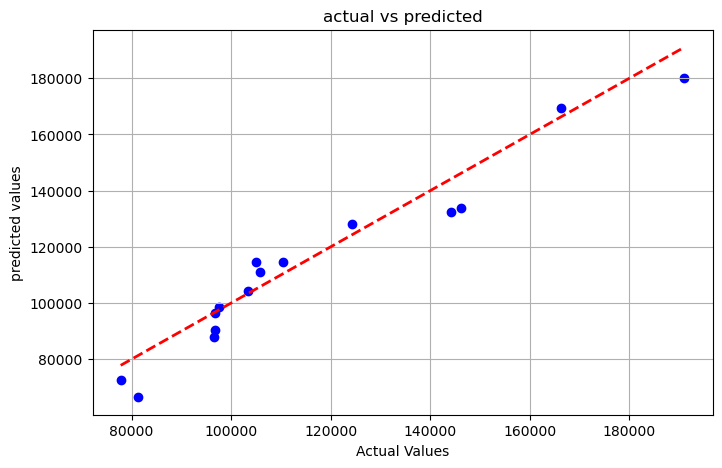

In [41]:
plt.figure(figsize = (8,5))
plt.scatter(y_test, y_pred, color= 'blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth = 2)
plt.xlabel("Actual Values")
plt.ylabel("predicted values")
plt.title("actual vs predicted")
plt.grid(True)
plt.show()